# Geomatic – Mangrove and coastal vegetation baseline, Tarut Bay (Saudi Arabia)
**Arab Youth Space Hackathon 2026 – Challenge 813 (Ecosystem Health, Biodiversity & Blue Carbon) – proof of concept**

This notebook runs end-to-end on the small clipped inputs in `data/` (no credentials, no restricted data). It does **one thing honestly**:
it asks how well satellite data (NASA EMIT 285-band hyperspectral vs Sentinel-2 9-band multispectral) separate *dense tree cover / low vegetation / water-bare ground*
in a ~233 ha study area, against **80 points labelled visually by one analyst**, and what that implies for a carbon scenario.

What it does **not** claim: no UAV/drone data are used; no 2025-vs-2026 change or "degradation" is inferred; the largest dense patches were visually checked as mangrove on Esri imagery, but the whole dense-tree class is **not verified pixel by pixel**
(10 m imagery cannot confirm species); the carbon figure is a clearly labelled scenario, not a measurement.

| Input | Source | Date |
|---|---|---|
| EMIT L2A reflectance + mask | NASA EMIT / LP DAAC, granule `EMIT_L2A_RFL_001_20260812T110954_2622407_050` | 2026-08-12 11:09:54 UTC |
| Sentinel-2 L2A (9 bands) | Copernicus Sentinel data via Copernicus Browser, clipped to the study area | 2026-08-16 |
| Sample labels | one analyst, visual interpretation of Sentinel-2 true/false colour + NDVI, then 14 water points corrected (see below) | 2026-10-08/09 |

In [1]:
import sys, json, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path('..').resolve(); sys.path.insert(0, str(ROOT/'src'))
import geomatic as G
OUT = ROOT/'outputs'; OUT.mkdir(exist_ok=True)
s2, s2valid, s2geo = G.load_s2(ROOT/'data/sentinel2_20260816')
cube, ev, mask, gt = G.load_emit(ROOT/'data/emit_20260812')
print('Sentinel-2 grid', s2['B04'].shape, 'pixel size (m)', s2geo[2], 'valid px', int(s2valid.sum()), '= %.0f ha' % (s2valid.sum()*s2geo[2]*s2geo[3]/1e4))
print('EMIT cube', cube.shape, 'valid px', int(ev.sum()), '| mask bands', mask.shape[-1])

Sentinel-2 grid (147, 346) pixel size (m) 8.955914690751431 valid px 30223 = 237 ha
EMIT cube (22, 59, 285) valid px 717 | mask bands 8


## 1. EMIT quality masks inside the study area
Band order (cloud, cirrus, water, spacecraft, dilated cloud, aerosol optical depth, water vapour, aggregate flag) follows the EMIT L2A documentation; check against the product's own metadata if reusing.

In [2]:
names=['cloud','cirrus','water','spacecraft','dilated_cloud','aerosol_optical_depth','water_vapor','aggregate_flag']
q=pd.DataFrame({'band':names,'mean_in_study_area':[mask[...,i][ev].mean() for i in range(8)],'min':[mask[...,i][ev].min() for i in range(8)],'max':[mask[...,i][ev].max() for i in range(8)]})
q.to_csv(OUT/'emit_mask_summary.csv',index=False); q.round(3)

,band,mean_in_study_area,min,max
0,cloud,0.000,0.000,0.000
1,cirrus,0.000,0.000,0.000
2,water,0.139,0.000,1.000
3,spacecraft,0.000,0.000,0.000
4,dilated_cloud,0.000,0.000,0.000
5,aerosol_optical_depth,0.564,0.484,0.612
6,water_vapor,1.906,1.675,2.081
7,aggregate_flag,0.972,0.000,1.000


**Reading:** no cloud/cirrus flagged, but aerosol optical depth is ~0.5 (dust/haze) – EMIT red/NIR reflectance may be biased; ~14% of EMIT pixels are flagged water.

## 2. Co-registration of EMIT and Sentinel-2
EMIT geolocation is only good to tens of metres. We shift the Sentinel-2 grid on a ±120 m window and keep the shift that maximises the correlation of EMIT NDVI with Sentinel-2 NDVI averaged inside each EMIT pixel. **This shift is estimated from the same scene pair, so it is a calibration, not an independent check.**

no shift : r=0.729 rmse=0.349 n=666
best shift (S2 moved E,N metres): (30.0, -60.0)  r=0.853 rmse=0.361 n=713


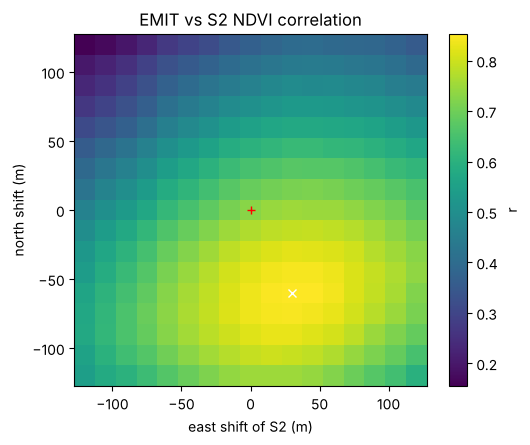

In [3]:
e_nd = G.ndvi(cube[...,G.EMIT_NIR], cube[...,G.EMIT_RED])
srch = G.offset_search(s2, s2valid, s2geo, e_nd, ev, gt)
base = srch[(srch.shift_east_m==0)&(srch.shift_north_m==0)].iloc[0]
best = srch.iloc[0]; SHIFT=(float(best.shift_east_m), float(best.shift_north_m))
srch.to_csv(OUT/'offset_search.csv',index=False)
print('no shift : r=%.3f rmse=%.3f n=%d' % (base.r, base.rmse, base.n_px))
print('best shift (S2 moved E,N metres):', SHIFT, ' r=%.3f rmse=%.3f n=%d' % (best.r, best.rmse, best.n_px))
piv = srch.pivot(index='shift_north_m', columns='shift_east_m', values='r')
plt.figure(figsize=(5.5,4.5)); plt.imshow(piv.values, origin='lower', extent=[piv.columns.min()-7.5, piv.columns.max()+7.5, piv.index.min()-7.5, piv.index.max()+7.5]); plt.colorbar(label='r'); plt.plot(0,0,'r+'); plt.plot(*SHIFT,'wx')
plt.xlabel('east shift of S2 (m)'); plt.ylabel('north shift (m)'); plt.title('EMIT vs S2 NDVI correlation'); plt.tight_layout(); plt.savefig(OUT/'offset_search.png',dpi=130); plt.show()

RMSE barely changes with the shift (≈0.35): registration explains part of the disagreement, not all. Other candidates: aerosol load in EMIT, the 4-day gap and tide, 60 m pixels mixing water and plants.

## 3. Visual reference labels
80 points were drawn stratified by Sentinel-2 NDVI (25 / 20 / 15 / 20), numbered at random, and labelled blind to the stratum. After labelling, 14 points that had NDVI ≤ 0.02 and appear dark blue in NIR-R-G (shallow turbid water that looks green in true colour) were corrected from *dense_tree* to *water_bare*. Raw labels are kept in `data/reference/raw_visual_labels.csv`.

In [4]:
lab = pd.read_csv(ROOT/'data/reference/points_labelled.csv')
print('corrected points:', int(lab.corrected.sum()))
print(pd.crosstab(lab.cls, lab.cls_corrected).rename_axis(index='raw', columns='corrected'))
print(lab.cls_corrected.value_counts().to_dict())

corrected points: 14
corrected   dense_tree  low_veg  water_bare
raw                                        
dense_tree          32        0          14
low_veg              0       14           0
water_bare           0        0          20
{'water_bare': 34, 'dense_tree': 32, 'low_veg': 14}


## 4. Estimators compared
Task: classify each point as dense_tree / low_veg / water_bare. Validation: repeated spatial-block cross-validation (250 m blocks), 80 points. Because the sample is stratified, an area-weighted accuracy is also given. **With n = 80 the 95 % interval is about ±0.10 – differences of a few points are not significant.**

In [5]:
shares, counts = G.stratum_weights(s2, s2valid)
print({k: round(v,3) for k,v in shares.items()})
df = G.point_features(ROOT/'data/reference/sample_points.geojson', ROOT/'data/reference/points_labelled.csv', s2, s2geo, cube, ev, gt, SHIFT)
df0 = G.point_features(ROOT/'data/reference/sample_points.geojson', ROOT/'data/reference/points_labelled.csv', s2, s2geo, cube, ev, gt, (0.0,0.0))
y = df.cls_corrected.values; w = G.point_weights(df, shares)
grp = (np.floor(df.X/250).astype(int)*1000 + np.floor(df.Y/250).astype(int)).values
s2c = ['s2_'+b for b in G.S2_BANDS]; ec = [f'e_{j}' for j in range(285)]
allm = np.ones(len(df), bool)
R = {}
nd_s2 = G.ndvi(df.s2_B08, df.s2_B04).values
R['S2 NDVI threshold (0.1/0.6)'] = G.score_fixed(G.threshold_class(nd_s2), y, allm, w)
m = df.emit_ok.values
nd_e = G.ndvi(df[f'e_{G.EMIT_NIR}'].fillna(0), df[f'e_{G.EMIT_RED}'].fillna(0)).values
R['EMIT NDVI threshold (S2 thresholds, shifted)'] = G.score_fixed(G.threshold_class(nd_e), y, m, w)
R['S2 RF red+NIR'] = G.spatial_cv(df[['s2_B04','s2_B08']].values, y, grp, allm, w)
R['S2 RF 9 bands'] = G.spatial_cv(df[s2c].values, y, grp, allm, w)
R['EMIT RF 285 bands (shifted)'] = G.spatial_cv(df[ec].fillna(0).values, y, grp, m, w)
m0 = df0.emit_ok.values
R['EMIT RF 285 bands (no shift)'] = G.spatial_cv(df0[ec].fillna(0).values, y, grp, m0, w)
res = pd.DataFrame(R).T[['oa','oa_area_weighted','n']]; res['ci95_halfwidth'] = 1.96*np.sqrt(res.oa*(1-res.oa)/res.n)
res.round(3).to_csv(OUT/'comparison_results.csv'); res.round(3)

{'A_dense_ndvi_gt0.6': 0.156, 'B_mid_ndvi_0.3_0.6': 0.253, 'C_low_ndvi_0.1_0.3': 0.184, 'D_water_bare_ndvi_le0.1': 0.407}


,oa,oa_area_weighted,n,ci95_halfwidth
S2 NDVI threshold (0.1/0.6),0.612,0.654,80.0,0.107
"EMIT NDVI threshold (S2 thresholds, shifted)",0.300,0.359,80.0,0.100
S2 RF red+NIR,0.633,0.662,80.0,0.106
S2 RF 9 bands,0.656,0.691,80.0,0.104
EMIT RF 285 bands (shifted),0.647,0.655,80.0,0.105
EMIT RF 285 bands (no shift),0.508,0.525,79.0,0.110


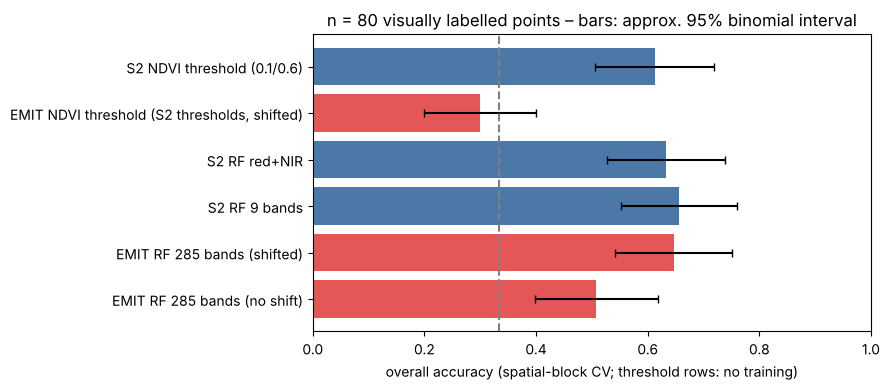

In [6]:
fig, ax = plt.subplots(figsize=(9,4)); r = res.iloc[::-1]
ax.barh(r.index, r.oa, xerr=r.ci95_halfwidth, color=['#e45756' if 'EMIT' in i else '#4c78a8' for i in r.index], capsize=3)
ax.axvline(1/3, ls='--', c='gray'); ax.set_xlim(0,1); ax.set_xlabel('overall accuracy (spatial-block CV; threshold rows: no training)')
ax.set_title('n = 80 visually labelled points – bars: approx. 95% binomial interval'); plt.tight_layout(); plt.savefig(OUT/'comparison_accuracy.png',dpi=130); plt.show()

**Reading:** Sentinel-2 (9 bands) and EMIT (285 bands, after co-registration) reach similar accuracy (~0.65); with this reference, hyperspectral did **not** beat multispectral. An NDVI threshold tuned for 10 m pixels does not transfer to 60 m EMIT pixels. Without registration EMIT drops to ~0.5. The potential advantages of EMIT (stress, moisture, pigment features) were **not tested** because no independent stress reference exists.

## 5. Area fractions and a carbon *scenario*

In [7]:
rng = np.random.default_rng(0)
def frac(df_, cls='dense_tree'):
    return sum(shares[s]*(df_[df_.stratum==s].cls_corrected==cls).mean() for s in shares)
def resample(d):
    return pd.concat([d[d.stratum==s].sample(frac=1.0, replace=True, random_state=int(rng.integers(1e9))) for s in shares])
boot = [frac(resample(df)) for _ in range(500)]
f_dense = frac(df); lo, hi = np.percentile(boot,[2.5,97.5])
area_ha = s2valid.sum()*s2geo[2]*s2geo[3]/1e4
print('dense-tree share of area: %.2f (95%% bootstrap %.2f-%.2f) of %.0f ha  ->  %.0f ha (%.0f-%.0f)' % (f_dense, lo, hi, area_ha, f_dense*area_ha, lo*area_ha, hi*area_ha))
SOC, SOC_SE = 43.0, 5.0   # Mg Corg/ha in the top 1 m, Red Sea Avicennia marina mangroves (Almahasheer et al. 2017, Sci Rep 7:9700)
sc = pd.DataFrame({'dense_tree_ha':[lo*area_ha, f_dense*area_ha, hi*area_ha], 'soil_C_Mg_per_ha':[SOC-SOC_SE, SOC, SOC+SOC_SE]}, index=['low','central','high'])
sc['soil_C_stock_Mg'] = sc.dense_tree_ha*sc.soil_C_Mg_per_ha; sc.round(1).to_csv(OUT/'carbon_scenario.csv'); sc.round(1)

dense-tree share of area: 0.27 (95% bootstrap 0.21-0.33) of 237 ha  ->  64 ha (49-78)


,dense_tree_ha,soil_C_Mg_per_ha,soil_C_stock_Mg
low,49.1,38.0,1866.5
central,64.1,43.0,2755.4
high,77.6,48.0,3722.8


**How to read the carbon scenario.** It multiplies the estimated dense-tree area by the *mean soil organic carbon stock reported for Red Sea mangroves* (43 ± 5 Mg C ha⁻¹, top 1 m; Almahasheer et al., 2017, *Sci. Rep.* 7:9700, doi:10.1038/s41598-017-10424-9). It is an **upper-bound illustration**: it assumes the dense-tree class is all mangrove, that Tarut Bay soils resemble Red Sea soils, and it ignores biomass. No height or field data were available, so biomass carbon was not estimated. The low/high rows combine only the area interval and the reported standard error.

In [8]:
json.dump({'shift_east_north_m':SHIFT,'offset_r_no_shift':float(base.r),'offset_r_best':float(best.r),'dense_tree_share':float(f_dense),'dense_tree_share_95ci':[float(lo),float(hi)],'area_ha_valid':float(area_ha),'n_points':int(len(df)),'stratum_area_shares':shares}, open(OUT/'metrics.json','w'), indent=1)
print(open(OUT/'metrics.json').read())

{
 "shift_east_north_m": [
  30.0,
  -60.0
 ],
 "offset_r_no_shift": 0.7289377034016676,
 "offset_r_best": 0.8527571465047559,
 "dense_tree_share": 0.27037995237064305,
 "dense_tree_share_95ci": [
  0.2072503698491737,
  0.32725421267229565
 ],
 "area_ha_valid": 236.9980610052241,
 "n_points": 80,
 "stratum_area_shares": {
  "A_dense_ndvi_gt0.6": 0.15638305549541748,
  "B_mid_ndvi_0.3_0.6": 0.2527603377354406,
  "C_low_ndvi_0.1_0.3": 0.18373385292631883,
  "D_water_bare_ndvi_le0.1": 0.40712275384282315
 }
}
